In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [3]:
n_points = 1500

x = rng.uniform(0, 1000, n_points)
y = rng.uniform(0, 800, n_points)

elevation = (
    112
    + 0.008 * x
    - 0.004 * y
    + 2.5 * np.sin(x / 150)
    + rng.normal(0, 0.25, n_points)
)

survey_data = pd.DataFrame({
    "point_id": [f"P{i:04d}" for i in range(1, n_points + 1)],
    "project_id": "SITE_104",
    "x_m": x.round(3),
    "y_m": y.round(3),
    "elevation_m": elevation.round(3),
    "quality": rng.choice(
        ["good", "fair", "poor"],
        n_points,
        p=[0.86, 0.11, 0.03]
    ),
    "collected_at": pd.date_range(
        "2026-08-10 08:00",
        periods=n_points,
        freq="30s"
    )
})

survey_data.head()

,point_id,project_id,x_m,y_m,elevation_m,quality,collected_at
0,P0001,SITE_104,773.956,537.483,114.052,fair,2026-08-10 08:00:00
1,P0002,SITE_104,438.878,768.470,112.784,good,2026-08-10 08:00:30
2,P0003,SITE_104,858.598,296.730,115.671,good,2026-08-10 08:01:00
3,P0004,SITE_104,697.368,340.065,113.282,good,2026-08-10 08:01:30
4,P0005,SITE_104,94.177,649.698,111.979,good,2026-08-10 08:02:00


In [4]:
print(f"Survey points: {len(survey_data):,}")
print(f"Columns: {survey_data.shape[1]}")
print(f"Duplicate point IDs: {survey_data['point_id'].duplicated().sum()}")
print(f"Missing values: {survey_data.isna().sum().sum()}")

survey_data.describe(include="all")

Survey points: 1,500
Columns: 7
Duplicate point IDs: 0
Missing values: 0


,point_id,project_id,x_m,y_m,elevation_m,quality,collected_at
count,1500,1500,1500.000000,1500.000000,1500.000000,1500,1500
unique,1500,1,NaN,NaN,NaN,3,NaN
top,P1500,SITE_104,NaN,NaN,NaN,good,NaN
freq,1,1500,NaN,NaN,NaN,1303,NaN
mean,NaN,NaN,499.643444,399.510251,114.443988,NaN,2026-08-10 14:14:45.000000256
min,NaN,NaN,0.519000,0.455000,108.969000,NaN,2026-08-10 08:00:00
25%,NaN,NaN,240.935250,197.007750,113.196500,NaN,2026-08-10 11:07:22.500000
50%,NaN,NaN,494.066500,397.436500,114.280500,NaN,2026-08-10 14:14:45
75%,NaN,NaN,758.893750,603.080750,115.474750,NaN,2026-08-10 17:22:07.500000
max,NaN,NaN,999.422000,799.812000,120.645000,NaN,2026-08-10 20:29:30


In [5]:
survey_test = survey_data.copy()

spike_idx = rng.choice(survey_test.index, 12, replace=False)
remaining = survey_test.index.difference(spike_idx)

missing_idx = rng.choice(remaining, 8, replace=False)
remaining = remaining.difference(missing_idx)

poor_idx = rng.choice(remaining, 20, replace=False)

survey_test.loc[spike_idx, "elevation_m"] += rng.choice(
    [20, 30, 45],
    size=len(spike_idx)
)

survey_test.loc[missing_idx[:4], "x_m"] = np.nan
survey_test.loc[missing_idx[4:], "y_m"] = np.nan

survey_test.loc[poor_idx, "quality"] = "poor"

duplicate_rows = survey_test.sample(6, random_state=42)
survey_test = pd.concat([survey_test, duplicate_rows], ignore_index=True)

print(f"Original points: {len(survey_data):,}")
print(f"Test points: {len(survey_test):,}")

Original points: 1,500
Test points: 1,506


In [6]:
injected_issues = {
    "elevation_spikes": survey_data.loc[spike_idx, "point_id"].tolist(),
    "missing_coordinates": survey_data.loc[missing_idx, "point_id"].tolist(),
    "poor_quality": survey_data.loc[poor_idx, "point_id"].tolist(),
    "duplicates": duplicate_rows["point_id"].tolist()
}

for issue, points in injected_issues.items():
    print(f"{issue}: {len(points)}")

elevation_spikes: 12
missing_coordinates: 8
poor_quality: 20
duplicates: 6


In [7]:
survey_test[
    survey_test["point_id"].isin(injected_issues["elevation_spikes"])
][["point_id", "x_m", "y_m", "elevation_m", "quality"]].head()

,point_id,x_m,y_m,elevation_m,quality
8,P0009,128.114,172.396,134.537,good
257,P0258,105.278,777.877,140.989,good
328,P0329,632.918,737.348,131.639,good
423,P0424,51.658,287.733,141.951,good
603,P0604,720.696,749.526,142.512,good


In [8]:
qa_results = survey_test.copy()

qa_results["missing_coordinate"] = (
    qa_results["x_m"].isna() |
    qa_results["y_m"].isna()
)

qa_results["duplicate_point"] = qa_results.duplicated(
    subset="point_id",
    keep=False
)

qa_results["poor_quality"] = (
    qa_results["quality"] == "poor"
)

print("Missing coordinates:", qa_results["missing_coordinate"].sum())
print("Duplicate records:", qa_results["duplicate_point"].sum())
print("Poor quality records:", qa_results["poor_quality"].sum())

Missing coordinates: 8
Duplicate records: 12
Poor quality records: 58


In [9]:
qa_summary = pd.DataFrame({
    "check": [
        "Missing coordinates",
        "Duplicate records",
        "Poor quality measurements"
    ],
    "records_flagged": [
        qa_results["missing_coordinate"].sum(),
        qa_results["duplicate_point"].sum(),
        qa_results["poor_quality"].sum()
    ]
})

qa_summary

,check,records_flagged
0,Missing coordinates,8
1,Duplicate records,12
2,Poor quality measurements,58


In [10]:
basic_issue_mask = (
    qa_results["missing_coordinate"] |
    qa_results["duplicate_point"] |
    qa_results["poor_quality"]
)

basic_issues = qa_results.loc[
    basic_issue_mask,
    [
        "point_id",
        "x_m",
        "y_m",
        "elevation_m",
        "quality",
        "missing_coordinate",
        "duplicate_point",
        "poor_quality"
    ]
]

print(f"Records requiring review: {len(basic_issues)}")

basic_issues.head(10)

Records requiring review: 78


,point_id,x_m,y_m,elevation_m,quality,missing_coordinate,duplicate_point,poor_quality
5,P0006,975.622,404.610,118.634,poor,False,False,True
9,P0010,450.386,596.163,113.571,poor,False,False,True
23,P0024,893.121,608.437,116.036,poor,False,False,True
46,P0047,387.478,192.742,116.228,poor,False,False,True
58,P0059,139.797,514.399,113.475,poor,False,False,True
65,P0066,553.579,368.745,113.854,poor,False,False,True
72,P0073,853.403,441.730,115.546,poor,False,False,True
82,P0083,814.020,NaN,115.196,good,True,False,False
108,P0109,96.391,343.966,112.864,poor,False,False,True
147,P0148,520.672,636.848,112.692,poor,False,False,True


In [11]:
from sklearn.neighbors import NearestNeighbors

valid_points = qa_results.dropna(
    subset=["x_m", "y_m", "elevation_m"]
).copy()

coordinates = valid_points[["x_m", "y_m"]].to_numpy()

neighbor_model = NearestNeighbors(n_neighbors=9)
neighbor_model.fit(coordinates)

distances, neighbor_indices = neighbor_model.kneighbors(coordinates)

print(f"Valid points analyzed: {len(valid_points):,}")

Valid points analyzed: 1,498


In [12]:
elevations = valid_points["elevation_m"].to_numpy()

local_medians = []
local_differences = []

for i, neighbors in enumerate(neighbor_indices):
    nearby = neighbors[1:]
    median_elevation = np.median(elevations[nearby])

    local_medians.append(median_elevation)
    local_differences.append(
        abs(elevations[i] - median_elevation)
    )

valid_points["local_elevation_median"] = local_medians
valid_points["elevation_difference"] = local_differences

valid_points[
    [
        "point_id",
        "elevation_m",
        "local_elevation_median",
        "elevation_difference"
    ]
].head()

,point_id,elevation_m,local_elevation_median,elevation_difference
0,P0001,114.052,114.0420,0.0100
1,P0002,112.784,112.9840,0.2000
2,P0003,115.671,116.3935,0.7225
3,P0004,113.282,113.7095,0.4275
4,P0005,111.979,112.0895,0.1105


In [13]:
valid_points[
    [
        "point_id",
        "x_m",
        "y_m",
        "elevation_m",
        "local_elevation_median",
        "elevation_difference"
    ]
].sort_values(
    "elevation_difference",
    ascending=False
).head(20)

,point_id,x_m,y_m,elevation_m,local_elevation_median,elevation_difference
1229,P1230,59.487,714.324,155.718,110.6205,45.0975
1194,P1195,872.859,699.881,159.988,115.0875,44.9005
1168,P1169,819.200,459.857,159.926,115.2355,44.6905
603,P0604,720.696,749.526,142.512,112.2925,30.2195
636,P0637,675.306,251.665,144.164,114.0220,30.1420
423,P0424,51.658,287.733,141.951,112.1655,29.7855
257,P0258,105.278,777.877,140.989,111.4635,29.5255
1103,P1104,839.174,602.768,135.263,114.7570,20.5060
1125,P1126,552.185,337.996,133.928,113.7460,20.1820
8,P0009,128.114,172.396,134.537,114.3785,20.1585


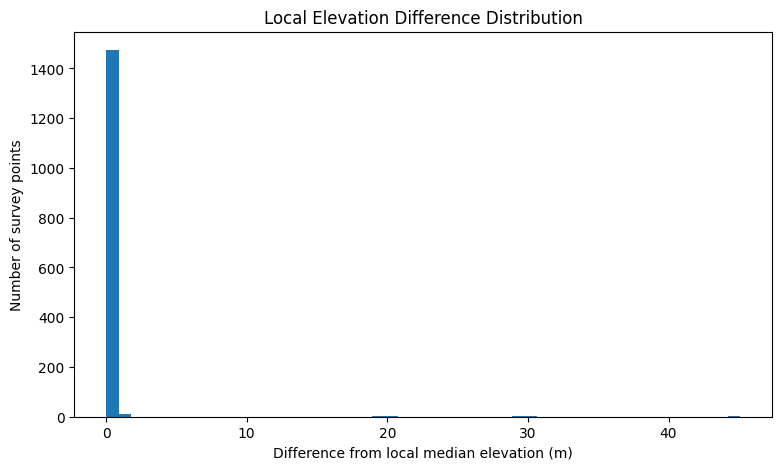

In [14]:
plt.figure(figsize=(9, 5))

plt.hist(
    valid_points["elevation_difference"],
    bins=50
)

plt.xlabel("Difference from local median elevation (m)")
plt.ylabel("Number of survey points")
plt.title("Local Elevation Difference Distribution")

plt.show()

In [15]:
differences = valid_points["elevation_difference"]

median_difference = differences.median()
mad = np.median(
    np.abs(differences - median_difference)
)

robust_score = (
    0.6745 *
    (differences - median_difference) /
    max(mad, 1e-9)
)

valid_points["elevation_anomaly_score"] = robust_score
valid_points["elevation_anomaly"] = robust_score > 6

print(f"Median local difference: {median_difference:.3f} m")
print(f"MAD: {mad:.3f} m")
print(
    "Elevation anomalies detected:",
    valid_points["elevation_anomaly"].sum()
)

Median local difference: 0.203 m
MAD: 0.119 m
Elevation anomalies detected: 14


In [16]:
detected_anomalies = valid_points[
    valid_points["elevation_anomaly"]
].sort_values(
    "elevation_anomaly_score",
    ascending=False
)

detected_anomalies[
    [
        "point_id",
        "x_m",
        "y_m",
        "elevation_m",
        "local_elevation_median",
        "elevation_difference",
        "elevation_anomaly_score"
    ]
].head(20)

,point_id,x_m,y_m,elevation_m,local_elevation_median,elevation_difference,elevation_anomaly_score
1229,P1230,59.487,714.324,155.718,110.6205,45.0975,254.466461
1194,P1195,872.859,699.881,159.988,115.0875,44.9005,253.349852
1168,P1169,819.200,459.857,159.926,115.2355,44.6905,252.159558
603,P0604,720.696,749.526,142.512,112.2925,30.2195,170.136957
636,P0637,675.306,251.665,144.164,114.0220,30.1420,169.697682
423,P0424,51.658,287.733,141.951,112.1655,29.7855,167.677016
257,P0258,105.278,777.877,140.989,111.4635,29.5255,166.203318
1103,P1104,839.174,602.768,135.263,114.7570,20.5060,115.080186
1125,P1126,552.185,337.996,133.928,113.7460,20.1820,113.243732
8,P0009,128.114,172.396,134.537,114.3785,20.1585,113.110533


In [17]:
true_anomalies = set(injected_issues["elevation_spikes"])
predicted_anomalies = set(
    detected_anomalies["point_id"]
)

true_positives = true_anomalies & predicted_anomalies
false_positives = predicted_anomalies - true_anomalies
false_negatives = true_anomalies - predicted_anomalies

print(f"True positives: {len(true_positives)}")
print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

True positives: 12
False positives: 2
False negatives: 0


In [19]:
tp = len(true_positives)
fp = len(false_positives)
fn = len(false_negatives)

precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall)
    else 0
)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 score:  {f1:.3f}")

Precision: 0.857
Recall:    1.000
F1 score:  0.923


In [20]:
validation_summary = pd.DataFrame({
    "metric": [
        "Injected anomalies",
        "Detected anomalies",
        "True positives",
        "False positives",
        "False negatives",
        "Precision",
        "Recall",
        "F1 score"
    ],
    "value": [
        len(true_anomalies),
        len(predicted_anomalies),
        tp,
        fp,
        fn,
        round(precision, 3),
        round(recall, 3),
        round(f1, 3)
    ]
})

validation_summary

,metric,value
0,Injected anomalies,12.000
1,Detected anomalies,14.000
2,True positives,12.000
3,False positives,2.000
4,False negatives,0.000
5,Precision,0.857
6,Recall,1.000
7,F1 score,0.923


In [21]:
if false_positives:
    print("False positives:")
    display(
        valid_points[
            valid_points["point_id"].isin(false_positives)
        ][
            [
                "point_id",
                "elevation_m",
                "local_elevation_median",
                "elevation_difference",
                "elevation_anomaly_score"
            ]
        ]
    )

if false_negatives:
    print("Missed anomalies:")
    display(
        valid_points[
            valid_points["point_id"].isin(false_negatives)
        ][
            [
                "point_id",
                "elevation_m",
                "local_elevation_median",
                "elevation_difference",
                "elevation_anomaly_score"
            ]
        ]
    )

False positives:


,point_id,elevation_m,local_elevation_median,elevation_difference,elevation_anomaly_score
409,P0410,118.478,117.2075,1.2705,6.052079
1084,P1085,120.645,119.2950,1.3500,6.502690


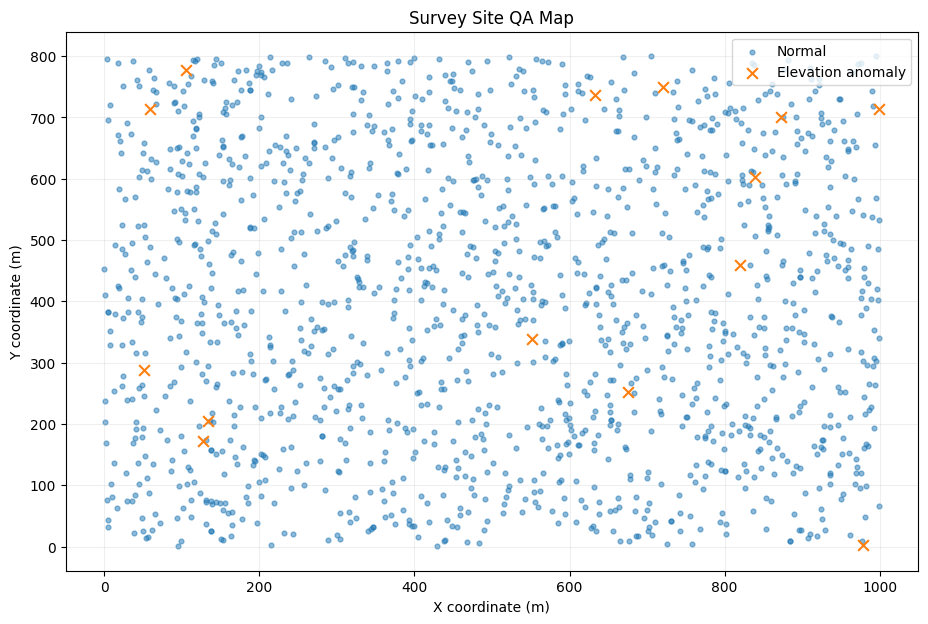

In [22]:
plt.figure(figsize=(11, 7))

normal_points = valid_points[
    ~valid_points["elevation_anomaly"]
]

anomaly_points = valid_points[
    valid_points["elevation_anomaly"]
]

plt.scatter(
    normal_points["x_m"],
    normal_points["y_m"],
    s=12,
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    anomaly_points["x_m"],
    anomaly_points["y_m"],
    s=60,
    marker="x",
    label="Elevation anomaly"
)

plt.xlabel("X coordinate (m)")
plt.ylabel("Y coordinate (m)")
plt.title("Survey Site QA Map")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

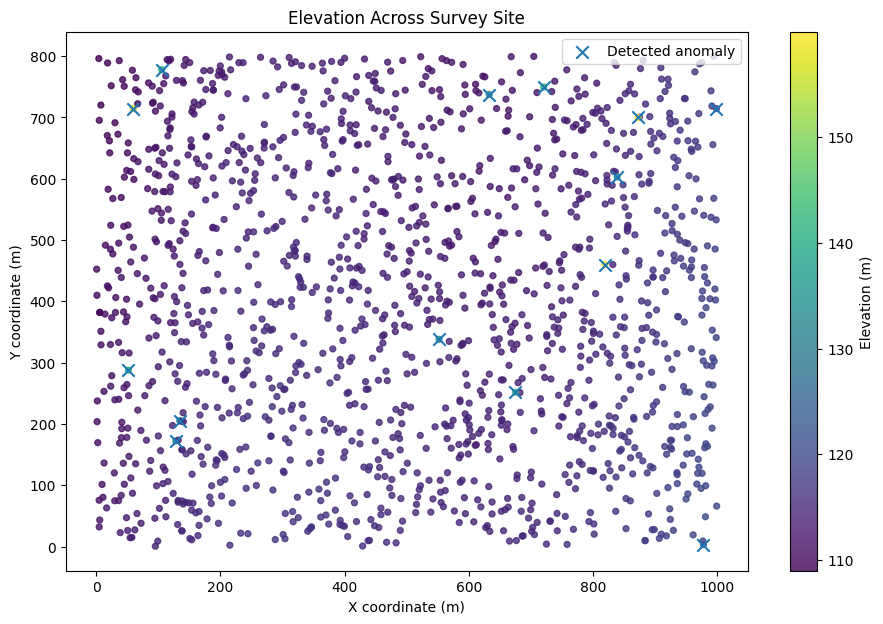

In [23]:
plt.figure(figsize=(11, 7))

plot = plt.scatter(
    valid_points["x_m"],
    valid_points["y_m"],
    c=valid_points["elevation_m"],
    s=18,
    alpha=0.8
)

plt.colorbar(plot, label="Elevation (m)")

plt.scatter(
    anomaly_points["x_m"],
    anomaly_points["y_m"],
    s=80,
    marker="x",
    label="Detected anomaly"
)

plt.xlabel("X coordinate (m)")
plt.ylabel("Y coordinate (m)")
plt.title("Elevation Across Survey Site")
plt.legend()

plt.show()

In [24]:
qa_results["elevation_anomaly"] = False

qa_results.loc[
    valid_points.index,
    "elevation_anomaly"
] = valid_points["elevation_anomaly"]

qa_results["requires_review"] = (
    qa_results["missing_coordinate"]
    | qa_results["duplicate_point"]
    | qa_results["poor_quality"]
    | qa_results["elevation_anomaly"]
)

qa_results["issue_count"] = qa_results[
    [
        "missing_coordinate",
        "duplicate_point",
        "poor_quality",
        "elevation_anomaly"
    ]
].sum(axis=1)

qa_results[
    [
        "point_id",
        "missing_coordinate",
        "duplicate_point",
        "poor_quality",
        "elevation_anomaly",
        "requires_review",
        "issue_count"
    ]
].head()

,point_id,missing_coordinate,duplicate_point,poor_quality,elevation_anomaly,requires_review,issue_count
0,P0001,False,False,False,False,False,0
1,P0002,False,False,False,False,False,0
2,P0003,False,False,False,False,False,0
3,P0004,False,False,False,False,False,0
4,P0005,False,False,False,False,False,0


In [25]:
def describe_issues(row):
    issues = []

    if row["missing_coordinate"]:
        issues.append("missing coordinate")

    if row["duplicate_point"]:
        issues.append("duplicate point")

    if row["poor_quality"]:
        issues.append("poor measurement quality")

    if row["elevation_anomaly"]:
        issues.append("local elevation anomaly")

    return ", ".join(issues) if issues else "none"


qa_results["issues"] = qa_results.apply(
    describe_issues,
    axis=1
)

qa_results.loc[
    qa_results["requires_review"],
    [
        "point_id",
        "elevation_m",
        "quality",
        "issue_count",
        "issues"
    ]
].head(15)

,point_id,elevation_m,quality,issue_count,issues
5,P0006,118.634,poor,1,poor measurement quality
8,P0009,134.537,good,1,local elevation anomaly
9,P0010,113.571,poor,1,poor measurement quality
23,P0024,116.036,poor,1,poor measurement quality
46,P0047,116.228,poor,1,poor measurement quality
58,P0059,113.475,poor,1,poor measurement quality
65,P0066,113.854,poor,1,poor measurement quality
72,P0073,115.546,poor,1,poor measurement quality
82,P0083,115.196,good,1,missing coordinate
108,P0109,112.864,poor,1,poor measurement quality


In [26]:
total_records = len(qa_results)
review_records = qa_results["requires_review"].sum()
clean_records = total_records - review_records

review_rate = review_records / total_records
clean_rate = clean_records / total_records

project_health = pd.DataFrame({
    "metric": [
        "Total records",
        "Clean records",
        "Records requiring review",
        "Clean rate",
        "Review rate"
    ],
    "value": [
        total_records,
        clean_records,
        review_records,
        f"{clean_rate:.1%}",
        f"{review_rate:.1%}"
    ]
})

project_health

,metric,value
0,Total records,1506
1,Clean records,1414
2,Records requiring review,92
3,Clean rate,93.9%
4,Review rate,6.1%


In [27]:
issue_breakdown = pd.DataFrame({
    "issue": [
        "Missing coordinates",
        "Duplicate records",
        "Poor measurement quality",
        "Elevation anomalies"
    ],
    "records": [
        qa_results["missing_coordinate"].sum(),
        qa_results["duplicate_point"].sum(),
        qa_results["poor_quality"].sum(),
        qa_results["elevation_anomaly"].sum()
    ]
})

issue_breakdown

,issue,records
0,Missing coordinates,8
1,Duplicate records,12
2,Poor measurement quality,58
3,Elevation anomalies,14


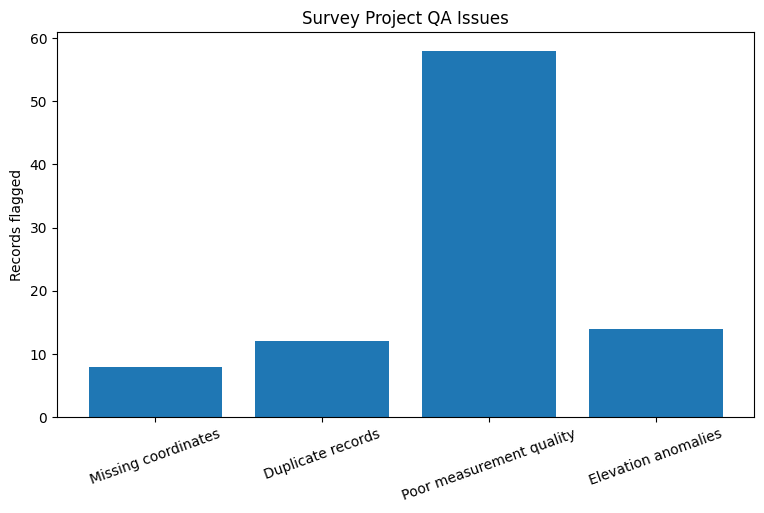

In [28]:
plt.figure(figsize=(9, 5))

plt.bar(
    issue_breakdown["issue"],
    issue_breakdown["records"]
)

plt.ylabel("Records flagged")
plt.title("Survey Project QA Issues")
plt.xticks(rotation=20)

plt.show()

In [29]:
elevation_issues = qa_results[
    qa_results["elevation_anomaly"]
].copy()

print(f"Project: SITE_104")
print(f"Elevation anomalies found: {len(elevation_issues)}")

elevation_issues[
    ["point_id", "x_m", "y_m", "elevation_m", "quality"]
].head(10)

Project: SITE_104
Elevation anomalies found: 14


,point_id,x_m,y_m,elevation_m,quality
8,P0009,128.114,172.396,134.537,good
257,P0258,105.278,777.877,140.989,good
328,P0329,632.918,737.348,131.639,good
409,P0410,999.105,714.442,118.478,good
423,P0424,51.658,287.733,141.951,good
603,P0604,720.696,749.526,142.512,good
636,P0637,675.306,251.665,144.164,good
678,P0679,134.367,205.377,134.014,good
1084,P1085,978.204,3.115,120.645,good
1103,P1104,839.174,602.768,135.263,good


In [30]:
support_summary = {
    "project": "SITE_104",
    "reported_issue": "Unexpected elevation values",
    "status": "Reproduced",
    "affected_records": len(elevation_issues),
    "recommended_action": "Review flagged measurements before production use",
    "engineering_escalation": "Recommended"
}

for key, value in support_summary.items():
    print(f"{key.replace('_', ' ').title()}: {value}")

Project: SITE_104
Reported Issue: Unexpected elevation values
Status: Reproduced
Affected Records: 14
Recommended Action: Review flagged measurements before production use
Engineering Escalation: Recommended


In [31]:
elevation_issues[
    ["point_id", "x_m", "y_m", "elevation_m", "quality", "issues"]
].to_csv("SITE_104_elevation_review.csv", index=False)

print("Review file created: SITE_104_elevation_review.csv")

Review file created: SITE_104_elevation_review.csv


In [32]:
customer_update = f"""
SITE_104 Project Update

We reproduced the reported elevation issue and identified
{len(elevation_issues)} records with unusual elevation values.

The affected points were flagged by comparing their elevations
with nearby survey measurements.

Recommended next step:
Review the flagged measurements before using them in production.

A CSV containing the affected records has been prepared for review.
"""

print(customer_update)


SITE_104 Project Update

We reproduced the reported elevation issue and identified
14 records with unusual elevation values.

The affected points were flagged by comparing their elevations
with nearby survey measurements.

Recommended next step:
Review the flagged measurements before using them in production.

A CSV containing the affected records has been prepared for review.



In [33]:
with open("SITE_104_customer_update.txt", "w") as file:
    file.write(customer_update.strip())

print("Customer update saved.")

Customer update saved.


In [34]:
print("SurveyFlow QA Summary")
print("---------------------")
print(f"Records processed: {len(qa_results):,}")
print(f"Records requiring review: {qa_results['requires_review'].sum()}")
print(f"Elevation anomalies: {qa_results['elevation_anomaly'].sum()}")
print(f"Anomaly detection precision: {precision:.1%}")
print(f"Anomaly detection recall: {recall:.1%}")
print("Customer issue status: Reproduced")

SurveyFlow QA Summary
---------------------
Records processed: 1,506
Records requiring review: 92
Elevation anomalies: 14
Anomaly detection precision: 85.7%
Anomaly detection recall: 100.0%
Customer issue status: Reproduced


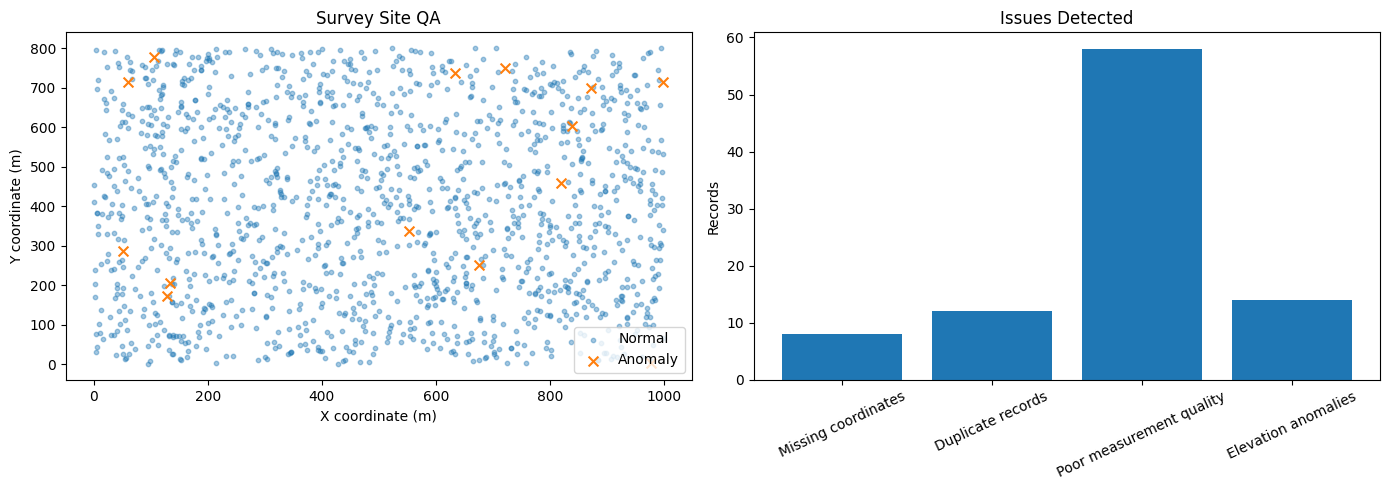

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    normal_points["x_m"],
    normal_points["y_m"],
    s=10,
    alpha=0.4,
    label="Normal"
)

axes[0].scatter(
    anomaly_points["x_m"],
    anomaly_points["y_m"],
    s=50,
    marker="x",
    label="Anomaly"
)

axes[0].set_title("Survey Site QA")
axes[0].set_xlabel("X coordinate (m)")
axes[0].set_ylabel("Y coordinate (m)")
axes[0].legend()

axes[1].bar(
    issue_breakdown["issue"],
    issue_breakdown["records"]
)

axes[1].set_title("Issues Detected")
axes[1].set_ylabel("Records")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [37]:
results = pd.DataFrame({
    "Metric": [
        "Records processed",
        "Records requiring review",
        "Elevation anomalies",
        "Detection precision",
        "Detection recall",
        "Customer issue"
    ],
    "Result": [
        f"{len(qa_results):,}",
        qa_results["requires_review"].sum(),
        qa_results["elevation_anomaly"].sum(),
        f"{precision:.1%}",
        f"{recall:.1%}",
        "Reproduced"
    ]
})

results

,Metric,Result
0,Records processed,"1,506"
1,Records requiring review,92
2,Elevation anomalies,14
3,Detection precision,85.7%
4,Detection recall,100.0%
5,Customer issue,Reproduced
